# Swap-less implementation of the QAOA

This notebook demonstrates the swap-less compilation of the QAOA, which is a hybrid quantum-classical algorithm designed to approximately solve optimization problems.  The QAOA works by definitng two Hamiltonians, a problem hamiltonain $H_P$ and a mixer hamiltonian, $H_X$. For many relevant problems the problem hamiltonain is given by an Ising-type Hamiltonian of the form

$$H_P = \sum_{k=1}^{n} \sum_{j < k} J_{jk} \bar{Z}_j \bar{Z}_k  + \sum_{j=1}^{n} h_j \bar{Z}_j.$$

Based on this diagonal problem hamiltonian, the mixer hamiltonia is defined as: 

$$H_X = \sum_{j=1}^{n} \bar{X}_j.$$

From these the related unitaties, $U_P(\gamma)$ and $U_X(\beta)$, can be generate as follows:

$$U_P(\gamma) = \exp(i\gamma H_P), \qquad U_X(\beta) = \exp(i\beta H_X).$$

Following the construction used in the temporal parity framework, in this notebook the problem unitary, $U_P(\gamma)$, and the mixer unitary, $U_X(\beta)$, are compiled separately. The notebook first generates the logical gate lists for both unitaries, then constructs the appropriate LHZ spanning-line data, and finally compiles each unitary into local physical rotations and nearest-neighbour CNOT gates.

The main functions used in the notebook are:

- `generate_qaoa_up_gates`: generates the logical $R_Z$ rotation list for the QAOA problem unitary $U_P(\gamma)$, including both one-body $h_j \bar{Z}_j$ terms and two-body $J_{jk}\bar{Z}_j\bar{Z}_k$ terms.

- `generate_qaoa_ux_gates`: generates the logical $R_X$ rotation list for the QAOA mixer unitary $U_X(\beta)$, with one logical $R_X$$ rotation for each qubit.

- `generate_qaoa_up_lhz_spanning_lines`: constructs the LHZ spanning-line schedule used to compile $U_P(\gamma)$. The schedule is designed to expose all required $Z$-parity labels appearing in the all-to-all Ising Hamiltonian.

- `generate_qaoa_ux_lhz_spanning_lines`: prepares the spanning-line data for $U_X(\beta)$. The initial and final line for the mixer unitary are taken to be the final line reached by the $U_P(\gamma)$ schedule.

- `compile_qaoa_up_with_lhz_spanning_lines`: compiles the logical $U_P(\gamma)$ operations into local physical $R_Z$ rotations and the CNOTs required to move between LHZ spanning lines.

- `compile_qaoa_ux_with_lhz_spanning_lines`: compiles the logical $U_X(\beta)$ operations using the logical $X$-line construction, producing the required CNOT layers and local $R_X$ rotations.

- `draw_compiled_ops_pennylane`: draws the compiled physical circuits using PennyLane, allowing the swap-less implementations of $U_P(\gamma)$ and $U_X(\beta)$ to be visualized.

The compiler output is compared with the theoretical resource estimates for the swap-less QAOA construction, including the CNOT count, single-qubit rotation count, CNOT depth, and single-qubit depth.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Scripts.QAOA_gates import (generate_qaoa_up_gates, generate_qaoa_ux_gates)
from Scripts.QAOA_spanning_lines import (generate_qaoa_up_lhz_spanning_lines, 
                                generate_qaoa_ux_lhz_spanning_lines)

from Scripts.QAOA_compiler import (compile_qaoa_up_with_lhz_spanning_lines,
                           compile_qaoa_ux_with_lhz_spanning_lines)

from Scripts.Circuit_plotter import draw_compiled_ops_pennylane

import numpy as np

# $U_P$

In [2]:
n = 5

gamma = 1

h_idx = np.arange(1,n+1)
J_idx = np.zeros((n, n), dtype=int)

counter = n+1
for k in range(n):
    for j in range(k):
        J_idx[j, k] = int(str(j + 1)+str(k + 1))
        J_idx[k, j] = int(str(j + 1)+str(k + 1))
        counter += 1
        
up_gates = generate_qaoa_up_gates(n, gamma,J=J_idx, h=h_idx)

up_data = generate_qaoa_up_lhz_spanning_lines(
    n,
    return_cnot_steps=True,
    verbose=False,
)

compiled_up, debug_up = compile_qaoa_up_with_lhz_spanning_lines(
    up_gates,
    n,
    spanning_data=up_data,
    return_debug=True,
    verbose=False,
)

print("CNOT count:", debug_up["cnot_count"], " \n Theoretical CNOT count:", int(n**2 - 2*n + 1))
print("Single qubit rotations:", debug_up['rotation_count'], "\n Theoretical Single qubit count:", int(n*(n+1)/2))
print('---------------------------------')
print("CNOT depth:", debug_up["cnot_depth"], " \n Theoretical CNOT depth:", int(2*n - 2))
print("Single qubit depth:", debug_up["single_qubit_depth"], " \n Theoretical single qubit depth:", int(np.ceil(0.5*n+0.5)))

CNOT count: 16  
 Theoretical CNOT count: 16
Single qubit rotations: 15 
 Theoretical Single qubit count: 15
---------------------------------
CNOT depth: 8  
 Theoretical CNOT depth: 8
Single qubit depth: 3  
 Theoretical single qubit depth: 3


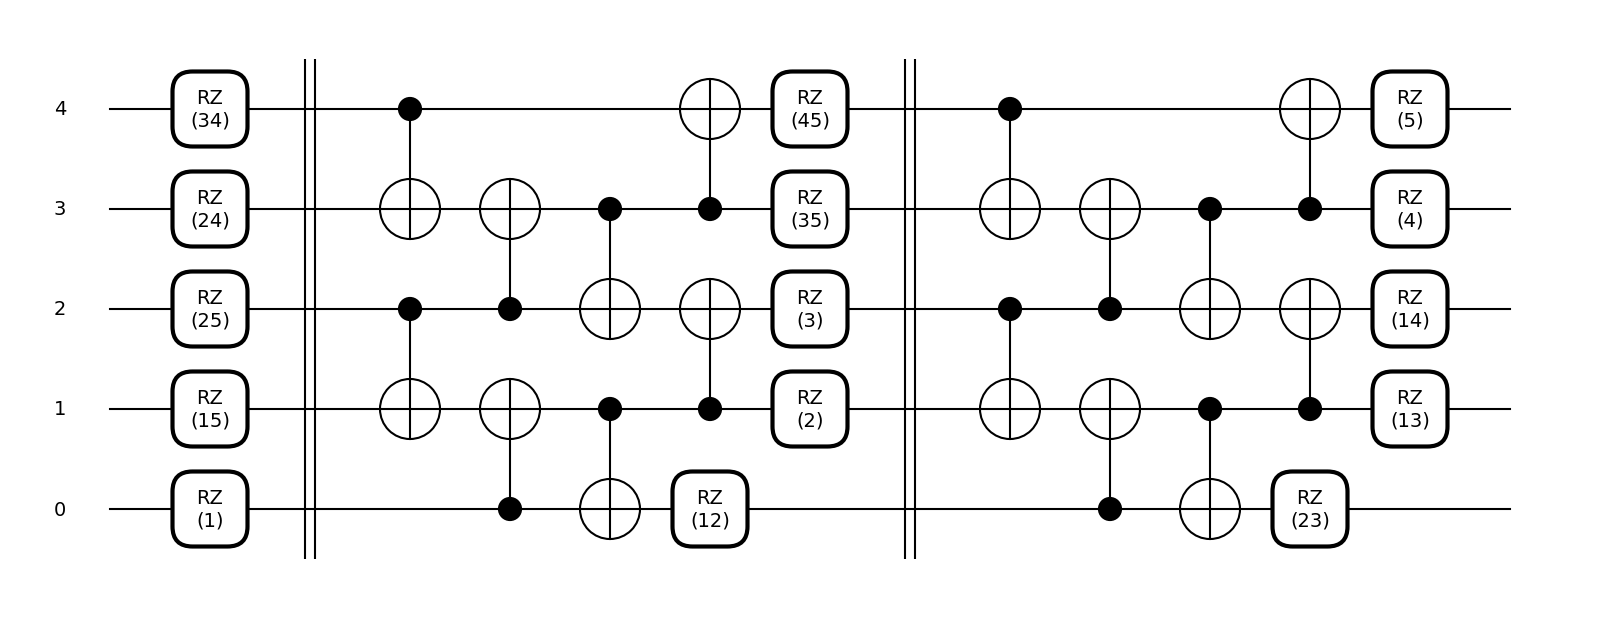

In [3]:
fig, ax = draw_compiled_ops_pennylane(compiled_ops=compiled_up, debug=debug_up, n_wires=n, decimals=0)

# $U_X$

In [9]:
beta = 1

ux_gates = generate_qaoa_ux_gates(n, beta)

ux_data = generate_qaoa_ux_lhz_spanning_lines(
    n,
    up_spanning_data=up_data,
    return_cnot_steps=True,
)

compiled_ux, debug_ux = compile_qaoa_ux_with_lhz_spanning_lines(
    ux_gates,
    n,
    ux_spanning_data=ux_data,
    return_debug=True,
    verbose=False,
)

print("CNOT count:", debug_ux["cnot_count"], " \n Theoretical CNOT count:", int(2*n - 2))
print("Single qubit rotations:", debug_ux['rotation_count'], "\n Theoretical Single qubit count:", int(n))
print('---------------------------------')
print("CNOT depth:", debug_ux["cnot_depth"], " \n Theoretical CNOT depth:", int(4))
print("Single qubit depth:", debug_ux["single_qubit_depth"], " \n Theoretical single qubit depth:", int(np.ceil(2)))

CNOT count: 6  
 Theoretical CNOT count: 8
Single qubit rotations: 5 
 Theoretical Single qubit count: 5
---------------------------------
CNOT depth: 4  
 Theoretical CNOT depth: 4
Single qubit depth: 1  
 Theoretical single qubit depth: 2


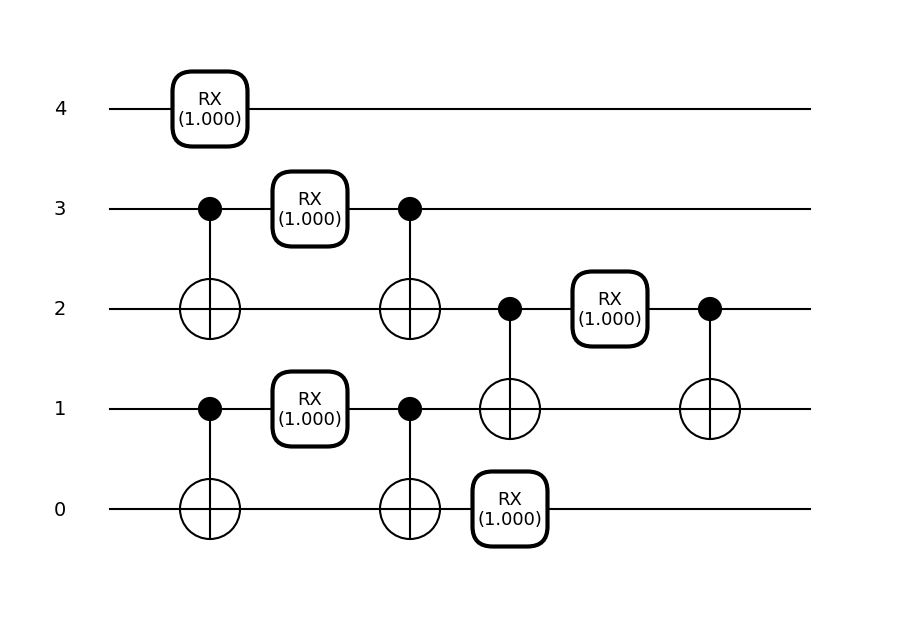

In [5]:
fig, ax = draw_compiled_ops_pennylane(compiled_ops=compiled_ux, debug=debug_ux, n_wires=n)